# Welfare Scheme Matcher — ML Pipeline Walkthrough
### IEMHACKS 4.0 — Social Issues Track

This notebook walks through the full ML pipeline end-to-end, for exploration,
sanity-checking, and generating charts/numbers for the pitch deck:

1. Load real scheme data
2. Generate synthetic citizen profiles
3. Label profiles using the deterministic rule engine (ground truth)
4. Encode features and train an XGBoost multi-label model
5. Evaluate performance per scheme
6. Explain predictions with SHAP
7. Run a live example prediction end-to-end

**Note:** this notebook reuses the exact same modules as the FastAPI backend
(`app/models/...`), so results here match what the API will return — this
isn't a separate throwaway experiment, it's the same pipeline.

Run this notebook from the `welfare-backend/` project root so the `app`
package imports correctly.


## 1. Setup & imports

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath("."))  # run from welfare-backend/ root

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import shap

from app.db.scheme_data import SCHEMES
from app.models.rules import is_eligible, eligibility_breakdown, check_all_schemes
from app.models.generate_synthetic_data import generate_profiles
from app.models.features import build_encoder, encode_features, profile_dict_to_df

pd.set_option("display.max_columns", None)
plt.rcParams["figure.figsize"] = (9, 5)


## 2. Explore the scheme data

In [2]:
schemes_df = pd.DataFrame(SCHEMES)[
    ["name", "min_income", "max_income", "age_min", "age_max", "gender", "state_scope"]
]
schemes_df


,name,min_income,max_income,age_min,age_max,gender,state_scope
0,PM-KISAN,0,NaN,18,100,any,central
1,Ayushman Bharat (PM-JAY),0,250000.0,0,100,any,central
2,PM Awas Yojana (Urban),0,1800000.0,18,100,any,central
3,National Scholarship Portal — Pre-Matric,0,250000.0,5,18,any,central
4,PM Ujjwala Yojana,0,100000.0,18,100,female,central
5,Sukanya Samriddhi Yojana,0,NaN,0,10,female,central
6,Atal Pension Yojana,0,NaN,18,40,any,central
7,PM Street Vendor's AtmaNirbhar Nidhi (PM SVANi...,0,NaN,18,100,any,central
8,e-Shram Registration Benefits,0,NaN,16,59,any,central
9,Indira Gandhi National Old Age Pension Scheme,0,100000.0,60,100,any,central


In [3]:
print(f"Total schemes loaded: {len(SCHEMES)}")


Total schemes loaded: 20


## 3. Generate synthetic citizen profiles

These are randomly generated profiles spanning realistic ranges — NOT real
citizens. They're used purely to create training data for the model, by
running each one through the rule engine below.

In [4]:
N_PROFILES = 8000
profiles_df = generate_profiles(N_PROFILES, seed=42)
profiles_df.head(10)


,income,age,occupation,gender,category,state,land_ownership,student_status,family_size
0,193700.0,16,student,female,SC,Uttar Pradesh,False,True,8
1,57800.0,46,farmer,male,ST,Maharashtra,True,False,1
2,289400.0,63,laborer,male,General,Karnataka,False,False,6
3,343400.0,54,domestic_worker,female,General,Assam,True,False,2
4,25400.0,67,student,female,OBC,Karnataka,False,True,7
5,45600.0,22,salaried,male,OBC,Telangana,False,False,6
6,165200.0,41,student,male,SC,Madhya Pradesh,False,True,5
7,110800.0,40,street_vendor,female,OBC,Odisha,True,False,6
8,145100.0,80,salaried,female,SC,Karnataka,False,False,1
9,68300.0,21,unorganized_worker,female,OBC,Punjab,False,False,3


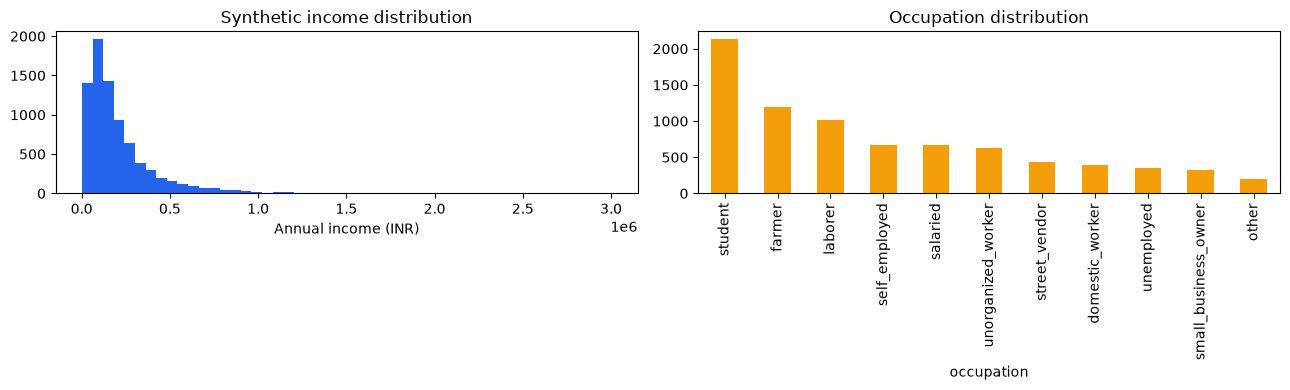

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))
axes[0].hist(profiles_df["income"], bins=50, color="#2563eb")
axes[0].set_title("Synthetic income distribution")
axes[0].set_xlabel("Annual income (INR)")

profiles_df["occupation"].value_counts().plot(kind="bar", ax=axes[1], color="#f59e0b")
axes[1].set_title("Occupation distribution")
plt.tight_layout()
plt.show()


## 4. Label profiles using the rule engine (ground truth)

Every profile is checked against every scheme's real eligibility criteria.
This is the source of truth the model learns from.

In [6]:
def build_label_matrix(profiles_df):
    labels = {}
    for scheme in SCHEMES:
        labels[scheme["name"]] = profiles_df.apply(
            lambda row: is_eligible(scheme, row.to_dict()), axis=1
        ).astype(int)
    return pd.DataFrame(labels)

labels_df = build_label_matrix(profiles_df)
labels_df.head()


,PM-KISAN,Ayushman Bharat (PM-JAY),PM Awas Yojana (Urban),National Scholarship Portal — Pre-Matric,PM Ujjwala Yojana,Sukanya Samriddhi Yojana,Atal Pension Yojana,PM Street Vendor's AtmaNirbhar Nidhi (PM SVANidhi),e-Shram Registration Benefits,Indira Gandhi National Old Age Pension Scheme,Indira Gandhi National Widow Pension Scheme,Indira Gandhi National Disability Pension Scheme,National Scholarship Portal — Post-Matric,PM Fasal Bima Yojana,Beti Bachao Beti Padhao — allied benefits,Pradhan Mantri Jan Dhan Yojana,Stand-Up India Scheme,PM Mudra Yojana,National Family Benefit Scheme,PM POSHAN (Mid-Day Meal Scheme)
0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,1,0,0,0,0
1,1,1,1,0,0,0,0,0,0,0,0,1,0,1,0,1,0,0,1,0
2,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,1,0,0,0,0
3,0,0,1,0,0,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0
4,0,1,1,0,1,0,0,0,0,1,1,1,0,0,0,1,0,0,0,0


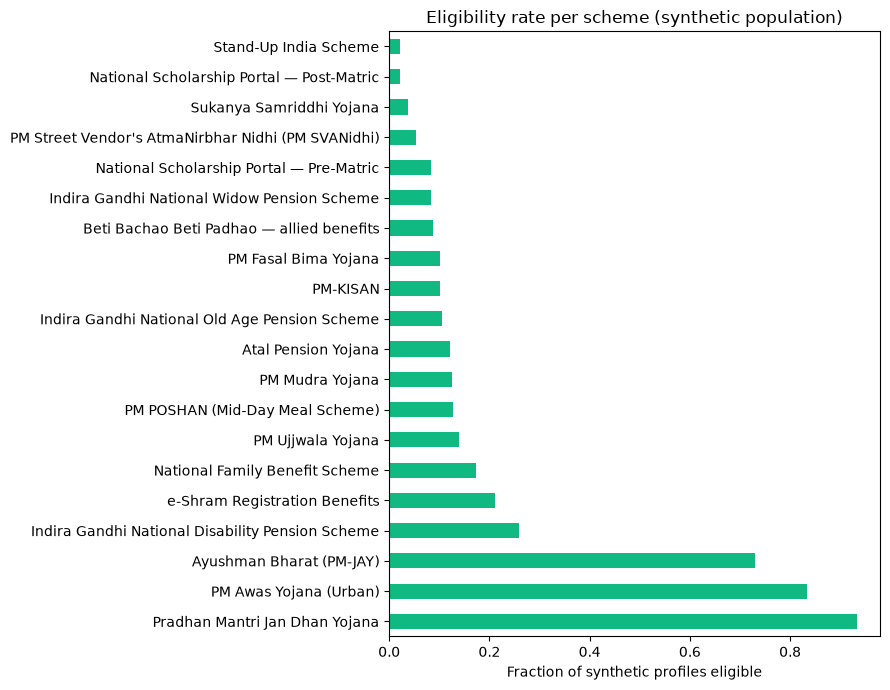

In [7]:
positive_rate = labels_df.mean().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 7))
positive_rate.plot(kind="barh", ax=ax, color="#10b981")
ax.set_xlabel("Fraction of synthetic profiles eligible")
ax.set_title("Eligibility rate per scheme (synthetic population)")
plt.tight_layout()
plt.show()


## 5. Encode features and train/test split

In [8]:
from sklearn.model_selection import train_test_split

usable_schemes = positive_rate[(positive_rate > 0.001) & (positive_rate < 0.999)].index.tolist()
labels_used = labels_df[usable_schemes]

encoder = build_encoder()
X = encode_features(profiles_df, encoder, fit=True)
y = labels_used.values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"Features: {X.shape[1]}   Schemes modeled: {len(usable_schemes)}")
print(f"Train rows: {len(X_train)}   Test rows: {len(X_test)}")


Features: 38   Schemes modeled: 20
Train rows: 6400   Test rows: 1600


## 6. Train the XGBoost multi-label model

In [9]:
from xgboost import XGBClassifier
from sklearn.multioutput import MultiOutputClassifier

base_model = XGBClassifier(
    n_estimators=150,
    max_depth=4,
    learning_rate=0.1,
    eval_metric="logloss",
    random_state=42,
)
model = MultiOutputClassifier(base_model)
model.fit(X_train, y_train)
print("Training complete.")


Training complete.


## 7. Evaluate per-scheme performance

**Important context for the pitch deck:** these scores are high because the
training labels come from *deterministic* rule-engine thresholds, not noisy
real-world outcomes — the model is learning to replicate and generalize
clean eligibility logic, not overcoming label noise. Frame it honestly as
*"high-fidelity generalization of rule-based eligibility, with added
ranking and explainability"* rather than claiming validated real-world
accuracy.

In [10]:
from sklearn.metrics import f1_score, accuracy_score

y_pred = model.predict(X_test)

rows = []
for i, name in enumerate(usable_schemes):
    rows.append({
        "scheme": name,
        "f1": round(f1_score(y_test[:, i], y_pred[:, i], zero_division=0), 3),
        "accuracy": round(accuracy_score(y_test[:, i], y_pred[:, i]), 3),
    })

metrics_df = pd.DataFrame(rows).sort_values("f1", ascending=False)
metrics_df


,scheme,f1,accuracy
0,Pradhan Mantri Jan Dhan Yojana,1.000,1.000
1,PM Awas Yojana (Urban),1.000,0.999
2,Ayushman Bharat (PM-JAY),1.000,1.000
4,e-Shram Registration Benefits,1.000,1.000
18,National Scholarship Portal — Post-Matric,1.000,1.000
6,PM Ujjwala Yojana,1.000,1.000
7,PM POSHAN (Mid-Day Meal Scheme),1.000,1.000
8,PM Mudra Yojana,1.000,1.000
11,PM-KISAN,1.000,1.000
9,Atal Pension Yojana,1.000,1.000


In [11]:
overall_f1 = f1_score(y_test, y_pred, average="micro", zero_division=0)
print(f"Overall micro-averaged F1: {overall_f1:.3f}")


Overall micro-averaged F1: 0.999


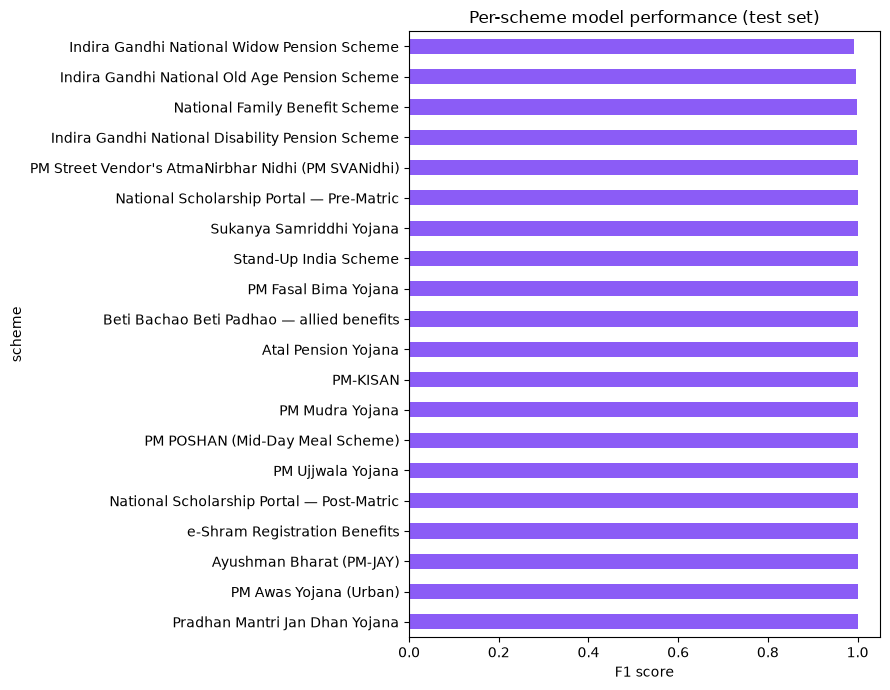

In [12]:
fig, ax = plt.subplots(figsize=(9, 7))
metrics_df.set_index("scheme")["f1"].plot(kind="barh", ax=ax, color="#8b5cf6")
ax.set_xlabel("F1 score")
ax.set_title("Per-scheme model performance (test set)")
ax.set_xlim(0, 1.05)
plt.tight_layout()
plt.show()


## 8. Explainability with SHAP

For a chosen scheme, see which features drive the model's predictions —
this is what powers the human-readable \"why you're eligible\" explanations
in the API, and directly answers the \"not a black box\" judging criterion.

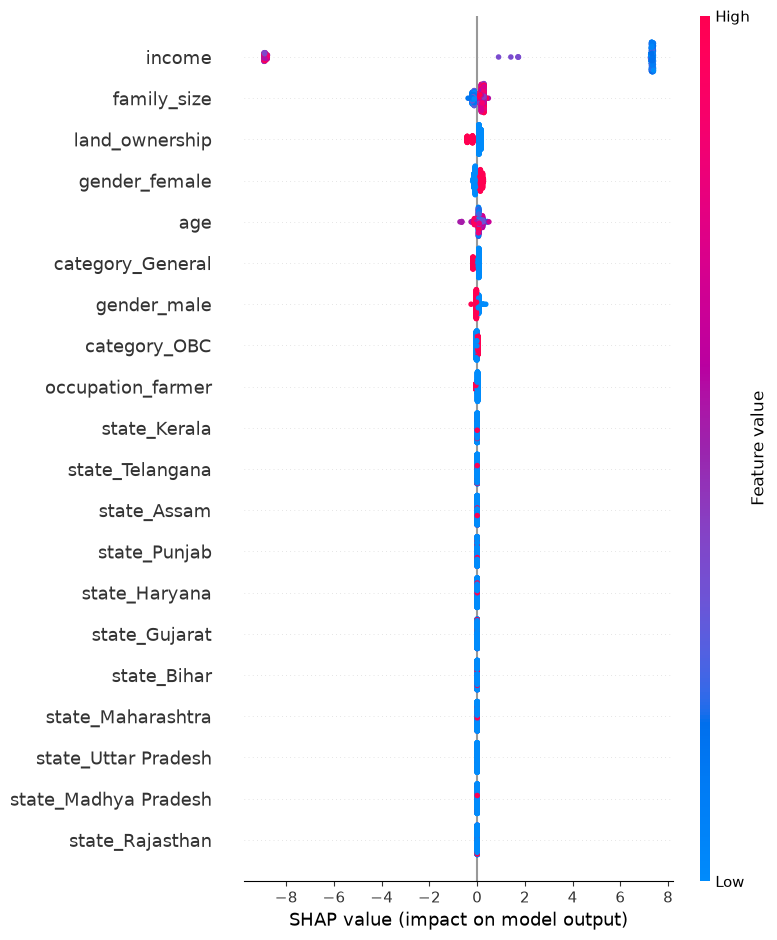

In [13]:
EXAMPLE_SCHEME = "Ayushman Bharat (PM-JAY)"
scheme_index = usable_schemes.index(EXAMPLE_SCHEME)
estimator = model.estimators_[scheme_index]

explainer = shap.TreeExplainer(estimator)
shap_values = explainer.shap_values(X_test.iloc[:500])

shap.summary_plot(shap_values, X_test.iloc[:500], show=True)


## 9. Live end-to-end prediction example

Simulate what the `/match` API endpoint will do: take one profile, predict
eligible schemes, and generate a plain-language reason for the top result.

In [14]:
example_profile = {
    "income": 140000,
    "age": 28,
    "occupation": "farmer",
    "gender": "female",
    "category": "ST",
    "state": "Odisha",
    "land_ownership": True,
    "student_status": False,
    "family_size": 5,
}

profile_row = profile_dict_to_df(example_profile)
X_live = encode_features(profile_row, encoder, fit=False)

results = []
for i, name in enumerate(usable_schemes):
    est = model.estimators_[i]
    proba = est.predict_proba(X_live)[0][1]
    results.append((name, proba))

results.sort(key=lambda r: r[1], reverse=True)
print("Top predicted schemes for example profile:\n")
for name, proba in results[:8]:
    print(f"  {proba:.2f}  {name}")


Top predicted schemes for example profile:

  1.00  Ayushman Bharat (PM-JAY)
  1.00  Pradhan Mantri Jan Dhan Yojana
  1.00  PM Awas Yojana (Urban)
  1.00  PM-KISAN
  1.00  PM Fasal Bima Yojana
  0.00  Atal Pension Yojana
  0.00  National Scholarship Portal — Post-Matric
  0.00  e-Shram Registration Benefits


In [15]:
# Cross-check against the deterministic rule engine directly
print("Rule-engine ground truth for the same profile:\n")
ground_truth = check_all_schemes(SCHEMES, example_profile)
for name, eligible in ground_truth.items():
    if eligible:
        print(f"  ✓ {name}")


Rule-engine ground truth for the same profile:

  ✓ PM-KISAN
  ✓ Ayushman Bharat (PM-JAY)
  ✓ PM Awas Yojana (Urban)
  ✓ PM Fasal Bima Yojana
  ✓ Pradhan Mantri Jan Dhan Yojana


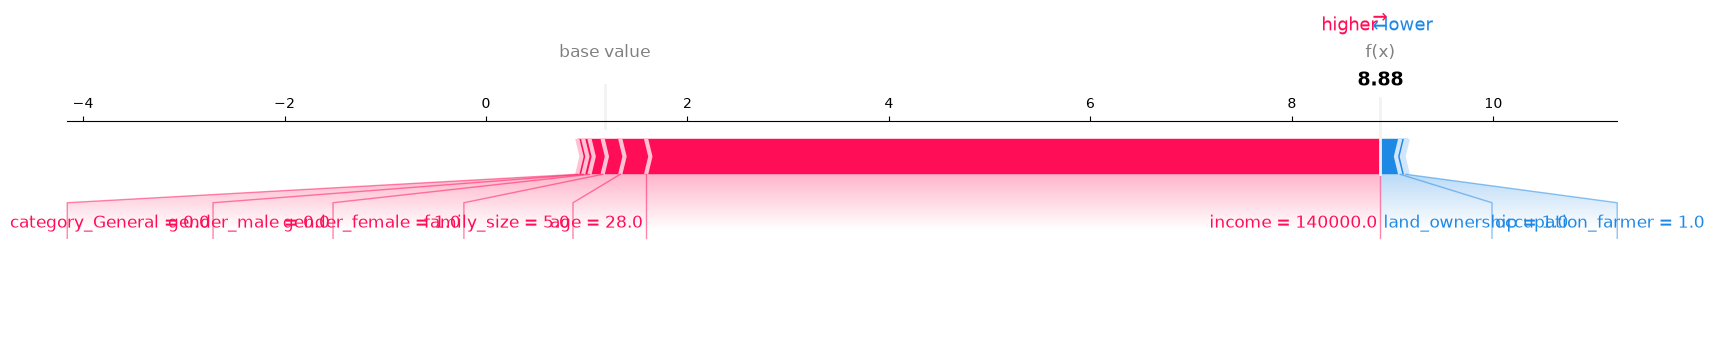

In [16]:
# SHAP explanation for the top-ranked scheme
top_scheme_name = results[0][0]
top_scheme_idx = usable_schemes.index(top_scheme_name)
top_estimator = model.estimators_[top_scheme_idx]

single_explainer = shap.TreeExplainer(top_estimator)
single_shap_values = single_explainer.shap_values(X_live)

shap.force_plot(
    single_explainer.expected_value[1] if isinstance(single_explainer.expected_value, (list, np.ndarray)) else single_explainer.expected_value,
    single_shap_values[0] if not isinstance(single_shap_values, list) else single_shap_values[1][0],
    X_live.iloc[0],
    matplotlib=True,
)


## 10. Next steps

This notebook mirrors `app/models/train_model.py` in the backend. To
retrain and save artifacts for the live API, run from the project root:

```bash
python -m app.models.train_model
```

The saved artifacts in `app/ml_artifacts/` are what `predict.py` and the
`/match` FastAPI endpoint load at startup.
